# Praktikum Pertemuan 5: Support Vector Machine (SVM)

**Mata Kuliah**: Machine Learning  
**Nama**: [Nur Adnan Yusri]  
**NIM**: [105841115623]  

---

## Import Libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import (make_classification, make_circles, make_moons, 
                              load_breast_cancer, load_wine)
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                            precision_score, recall_score, f1_score)
import warnings
warnings.filterwarnings('ignore')

# Settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print(" All libraries imported successfully!")

 All libraries imported successfully!


# TUGAS 1: SVM untuk Binary Classification (25 poin)

## 1.1. Load dan Split Data

In [20]:
# Load Breast Cancer dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

print(f"Dataset shape: {X.shape}")
print(f"Classes: {cancer.target_names}")
print(f"Class distribution: {np.bincount(y)}")

# Split 80-20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Dataset shape: (569, 30)
Classes: ['malignant' 'benign']
Class distribution: [212 357]

Training samples: 455
Testing samples: 114


## 1.2. Standardize Features

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features standardized")
print(f"Mean after scaling: {X_train_scaled.mean():.6f}")
print(f"Std after scaling: {X_train_scaled.std():.6f}")

✓ Features standardized
Mean after scaling: -0.000000
Std after scaling: 1.000000


## 1.3. Train SVM dengan 3 Kernels

In [22]:
kernels = ['linear', 'poly', 'rbf']
results = []

for kernel in kernels:
    print(f"\nTraining with {kernel.upper()} kernel...")
    
    if kernel == 'poly':
        svm = SVC(kernel=kernel, degree=3, gamma='scale', random_state=42)
    else:
        svm = SVC(kernel=kernel, gamma='scale', random_state=42)
    
    svm.fit(X_train_scaled, y_train)
    
    y_pred = svm.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        'Kernel': kernel.upper(),
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Support Vectors': len(svm.support_vectors_)
    })
    
    print(f"✓ Accuracy: {acc:.4f}")

results_df = pd.DataFrame(results)
print("\n" + "="*80)
print(results_df.to_string(index=False))
print("="*80)


Training with LINEAR kernel...
✓ Accuracy: 0.9737

Training with POLY kernel...
✓ Accuracy: 0.9123

Training with RBF kernel...
✓ Accuracy: 0.9825

Kernel  Accuracy  Precision   Recall  F1-Score  Support Vectors
LINEAR  0.973684   0.985915 0.972222  0.979021               32
  POLY  0.912281   0.878049 1.000000  0.935065              145
   RBF  0.982456   0.986111 0.986111  0.986111               97


## 1.4. Confusion Matrices

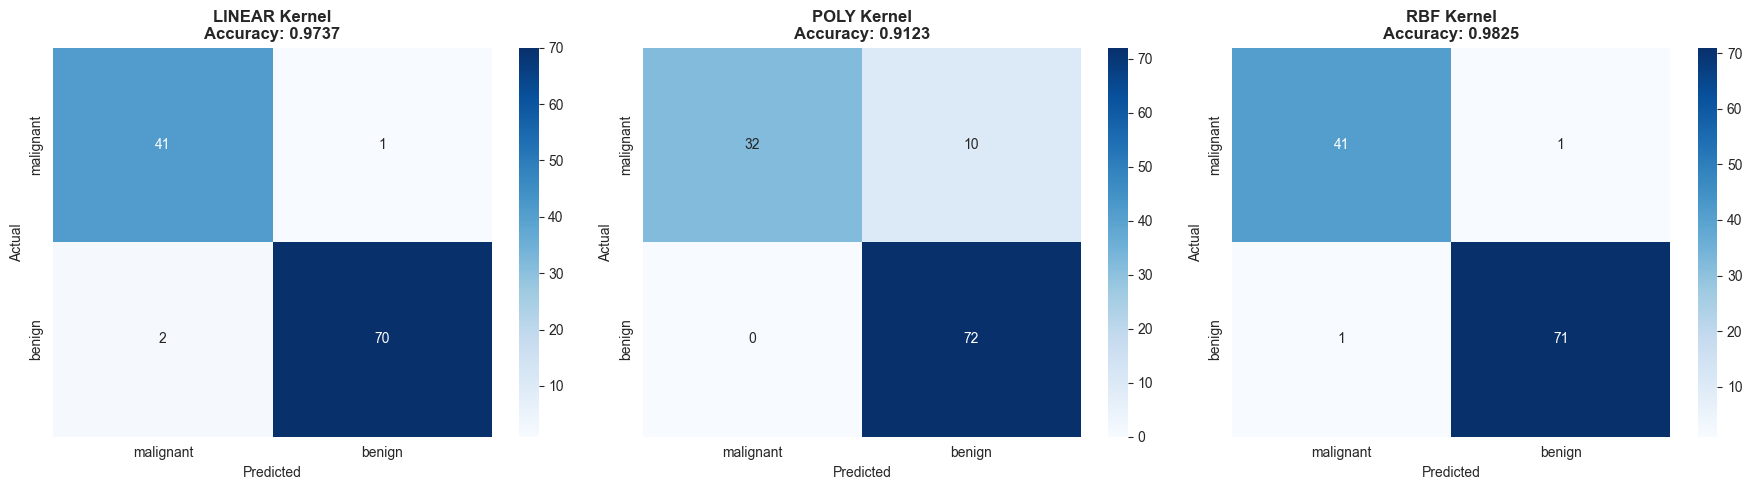

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, kernel in enumerate(kernels):
    if kernel == 'poly':
        svm = SVC(kernel=kernel, degree=3, gamma='scale', random_state=42)
    else:
        svm = SVC(kernel=kernel, gamma='scale', random_state=42)
    
    svm.fit(X_train_scaled, y_train)
    y_pred = svm.predict(X_test_scaled)
    
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=cancer.target_names,
                yticklabels=cancer.target_names)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_title(f'{kernel.upper()} Kernel\nAccuracy: {accuracy_score(y_test, y_pred):.4f}', 
                       fontweight='bold')

plt.tight_layout()
plt.show()

## 1.5. Analisis dan Kesimpulan

**[ISI ANALISIS ANDA DI SINI]**

- Kernel terbaik: ...
- Alasan: ...
- Perbandingan: ...

---

# TUGAS 2: Parameter Tuning Analysis (30 poin)

## 2.1. Load Wine Dataset

In [24]:
wine = load_wine()
X_wine, y_wine = wine.data, wine.target

# Convert to binary
y_wine_binary = (y_wine == 0).astype(int)

print(f"Dataset shape: {X_wine.shape}")
print(f"Binary classes: {np.bincount(y_wine_binary)}")

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wine, y_wine_binary, test_size=0.2, random_state=42, stratify=y_wine_binary
)

scaler_w = StandardScaler()
X_train_w_scaled = scaler_w.fit_transform(X_train_w)
X_test_w_scaled = scaler_w.transform(X_test_w)

Dataset shape: (178, 13)
Binary classes: [119  59]


## 2.2. Experiment dengan C dan Gamma

In [25]:
C_values = [0.01, 0.1, 1, 10, 100]
gamma_values = [0.001, 0.01, 0.1, 1, 10]

results_param = []

print("Running parameter experiments...")
for C in C_values:
    for gamma in gamma_values:
        svm = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)
        svm.fit(X_train_w_scaled, y_train_w)
        
        y_pred_train = svm.predict(X_train_w_scaled)
        y_pred_test = svm.predict(X_test_w_scaled)
        
        train_acc = accuracy_score(y_train_w, y_pred_train)
        test_acc = accuracy_score(y_test_w, y_pred_test)
        
        results_param.append({
            'C': C,
            'Gamma': gamma,
            'Train Acc': train_acc,
            'Test Acc': test_acc,
            'SV': len(svm.support_vectors_),
            'Gap': train_acc - test_acc
        })

df_param = pd.DataFrame(results_param)
print(f"\n✓ Completed {len(results_param)} experiments")

Running parameter experiments...

✓ Completed 25 experiments


## 2.3. Heatmaps Visualization

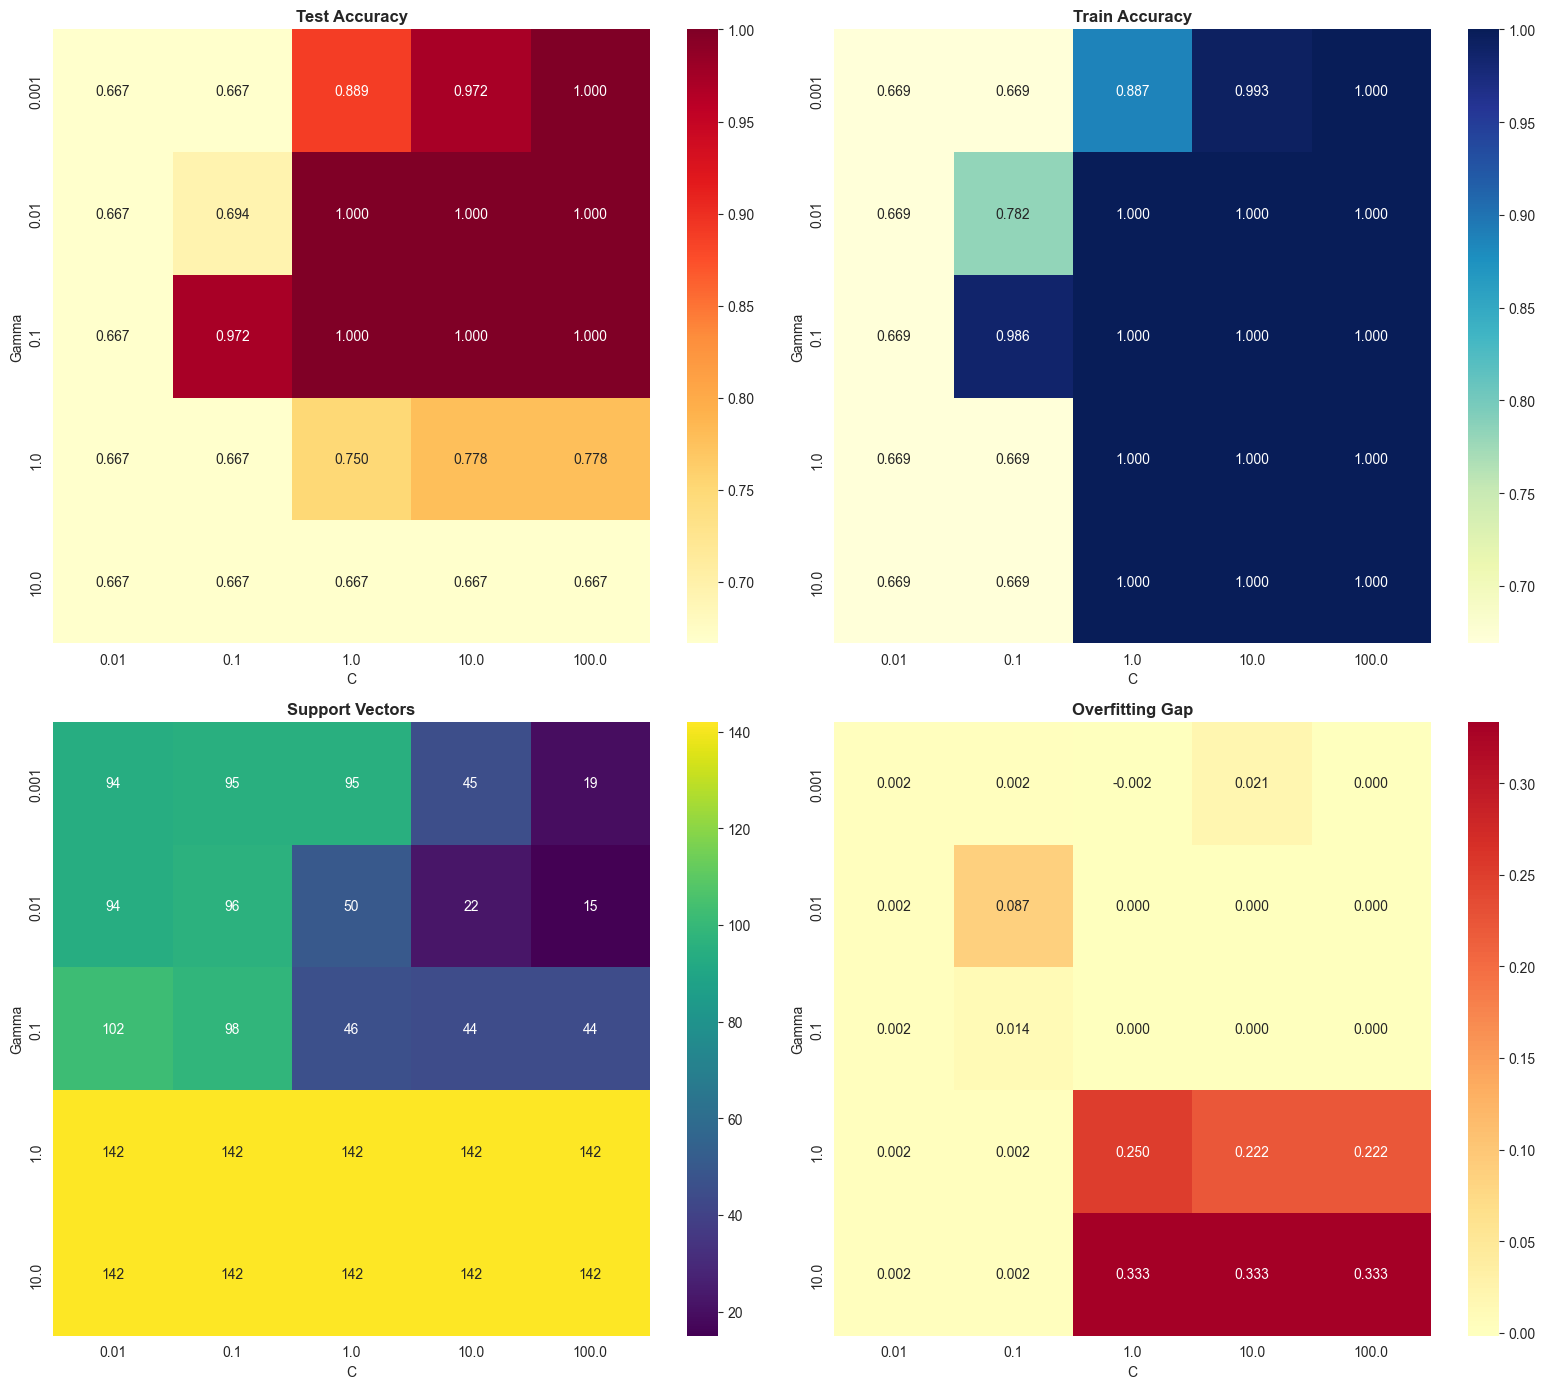

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Test Accuracy
pivot_test = df_param.pivot(index='Gamma', columns='C', values='Test Acc')
sns.heatmap(pivot_test, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0,0])
axes[0,0].set_title('Test Accuracy', fontweight='bold')

# Train Accuracy
pivot_train = df_param.pivot(index='Gamma', columns='C', values='Train Acc')
sns.heatmap(pivot_train, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[0,1])
axes[0,1].set_title('Train Accuracy', fontweight='bold')

# Support Vectors
pivot_sv = df_param.pivot(index='Gamma', columns='C', values='SV')
sns.heatmap(pivot_sv, annot=True, fmt='.0f', cmap='viridis', ax=axes[1,0])
axes[1,0].set_title('Support Vectors', fontweight='bold')

# Gap
pivot_gap = df_param.pivot(index='Gamma', columns='C', values='Gap')
sns.heatmap(pivot_gap, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=axes[1,1], center=0)
axes[1,1].set_title('Overfitting Gap', fontweight='bold')

plt.tight_layout()
plt.show()

## 2.4. Best Combination Analysis

In [27]:
# Best test accuracy
best_idx = df_param['Test Acc'].idxmax()
best = df_param.loc[best_idx]

print("BEST TEST ACCURACY:")
print(f"C = {best['C']}, Gamma = {best['Gamma']}")
print(f"Test Accuracy = {best['Test Acc']:.4f}")
print(f"Gap = {best['Gap']:.4f}")

# Most balanced
balanced_idx = df_param['Gap'].abs().idxmin()
balanced = df_param.loc[balanced_idx]

print("\nMOST BALANCED:")
print(f"C = {balanced['C']}, Gamma = {balanced['Gamma']}")
print(f"Gap = {balanced['Gap']:.4f}")

BEST TEST ACCURACY:
C = 1.0, Gamma = 0.01
Test Accuracy = 1.0000
Gap = 0.0000

MOST BALANCED:
C = 1.0, Gamma = 0.01
Gap = 0.0000


## 2.5. Analisis Overfitting/Underfitting


---

# TUGAS 3: Kernel Comparison - Non-Linear (25 poin)

## 3.1. Generate Non-Linear Datasets

In [28]:
# Helper function
def plot_svm_boundary(model, X, y, scaler=None, title='', ax=None):
    if ax is None:
        ax = plt.gca()
    
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    mesh_input = np.c_[xx.ravel(), yy.ravel()]
    if scaler:
        mesh_input = scaler.transform(mesh_input)
    
    Z = model.predict(mesh_input)
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='RdYlBu', s=50)
    
    if scaler:
        sv = scaler.inverse_transform(model.support_vectors_)
    else:
        sv = model.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=200, linewidth=2, 
               facecolors='none', edgecolors='lime', label='SV')
    
    ax.set_title(title, fontweight='bold')
    ax.legend()

# Generate datasets
X_circles, y_circles = make_circles(n_samples=300, noise=0.1, factor=0.5, random_state=42)
X_moons, y_moons = make_moons(n_samples=300, noise=0.15, random_state=42)

np.random.seed(42)
X_xor = np.random.randn(300, 2)
y_xor = np.logical_xor(X_xor[:, 0] > 0, X_xor[:, 1] > 0).astype(int)

datasets = [
    ('Circles', X_circles, y_circles),
    ('Moons', X_moons, y_moons),
    ('XOR', X_xor, y_xor)
]

print("✓ 3 non-linear datasets generated")

✓ 3 non-linear datasets generated


## 3.2. Visualize Raw Datasets

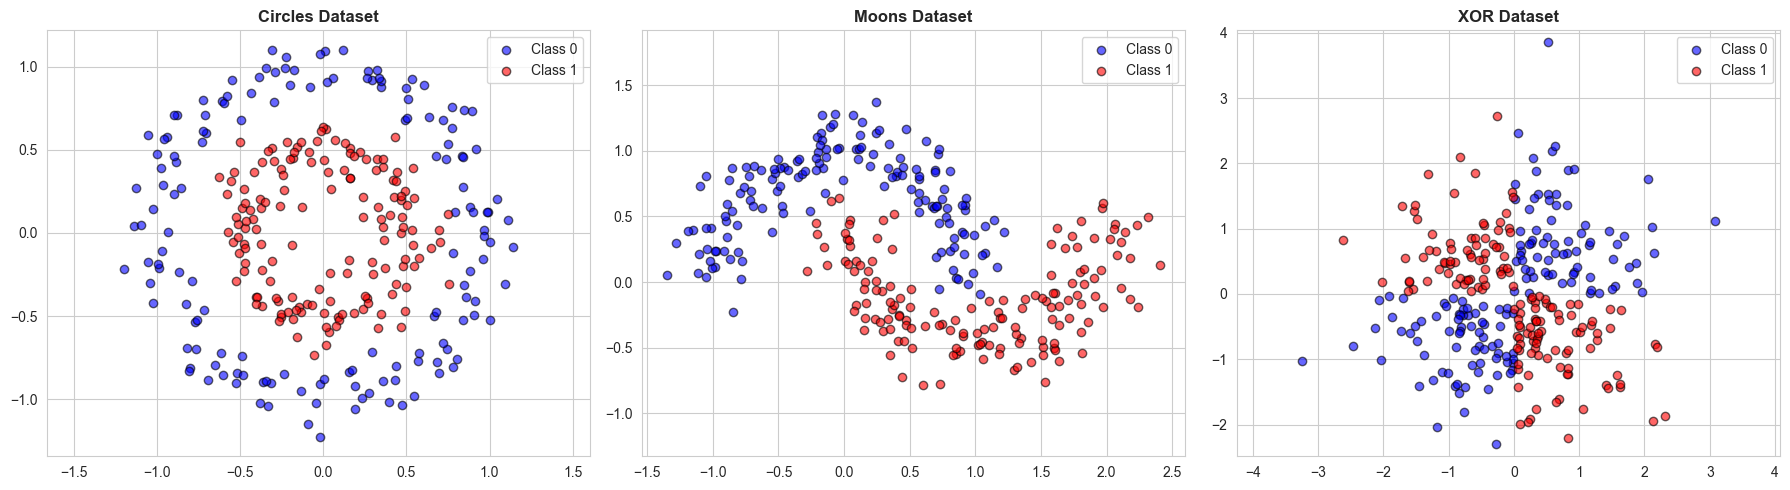

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, X, y) in enumerate(datasets):
    axes[idx].scatter(X[y==0][:, 0], X[y==0][:, 1], c='blue', label='Class 0', alpha=0.6, edgecolors='k')
    axes[idx].scatter(X[y==1][:, 0], X[y==1][:, 1], c='red', label='Class 1', alpha=0.6, edgecolors='k')
    axes[idx].set_title(f'{name} Dataset', fontweight='bold')
    axes[idx].legend()
    axes[idx].axis('equal')

plt.tight_layout()
plt.show()

## 3.3. Test 4 Kernels on Each Dataset


Dataset: Circles
  LINEAR: 0.4333
  POLY: 0.4333
  RBF: 1.0000
  SIGMOID: 0.6000

Dataset: Moons
  LINEAR: 0.9000
  POLY: 0.9167
  RBF: 1.0000
  SIGMOID: 0.7833

Dataset: XOR
  LINEAR: 0.6333
  POLY: 0.5333
  RBF: 0.9833
  SIGMOID: 0.5167


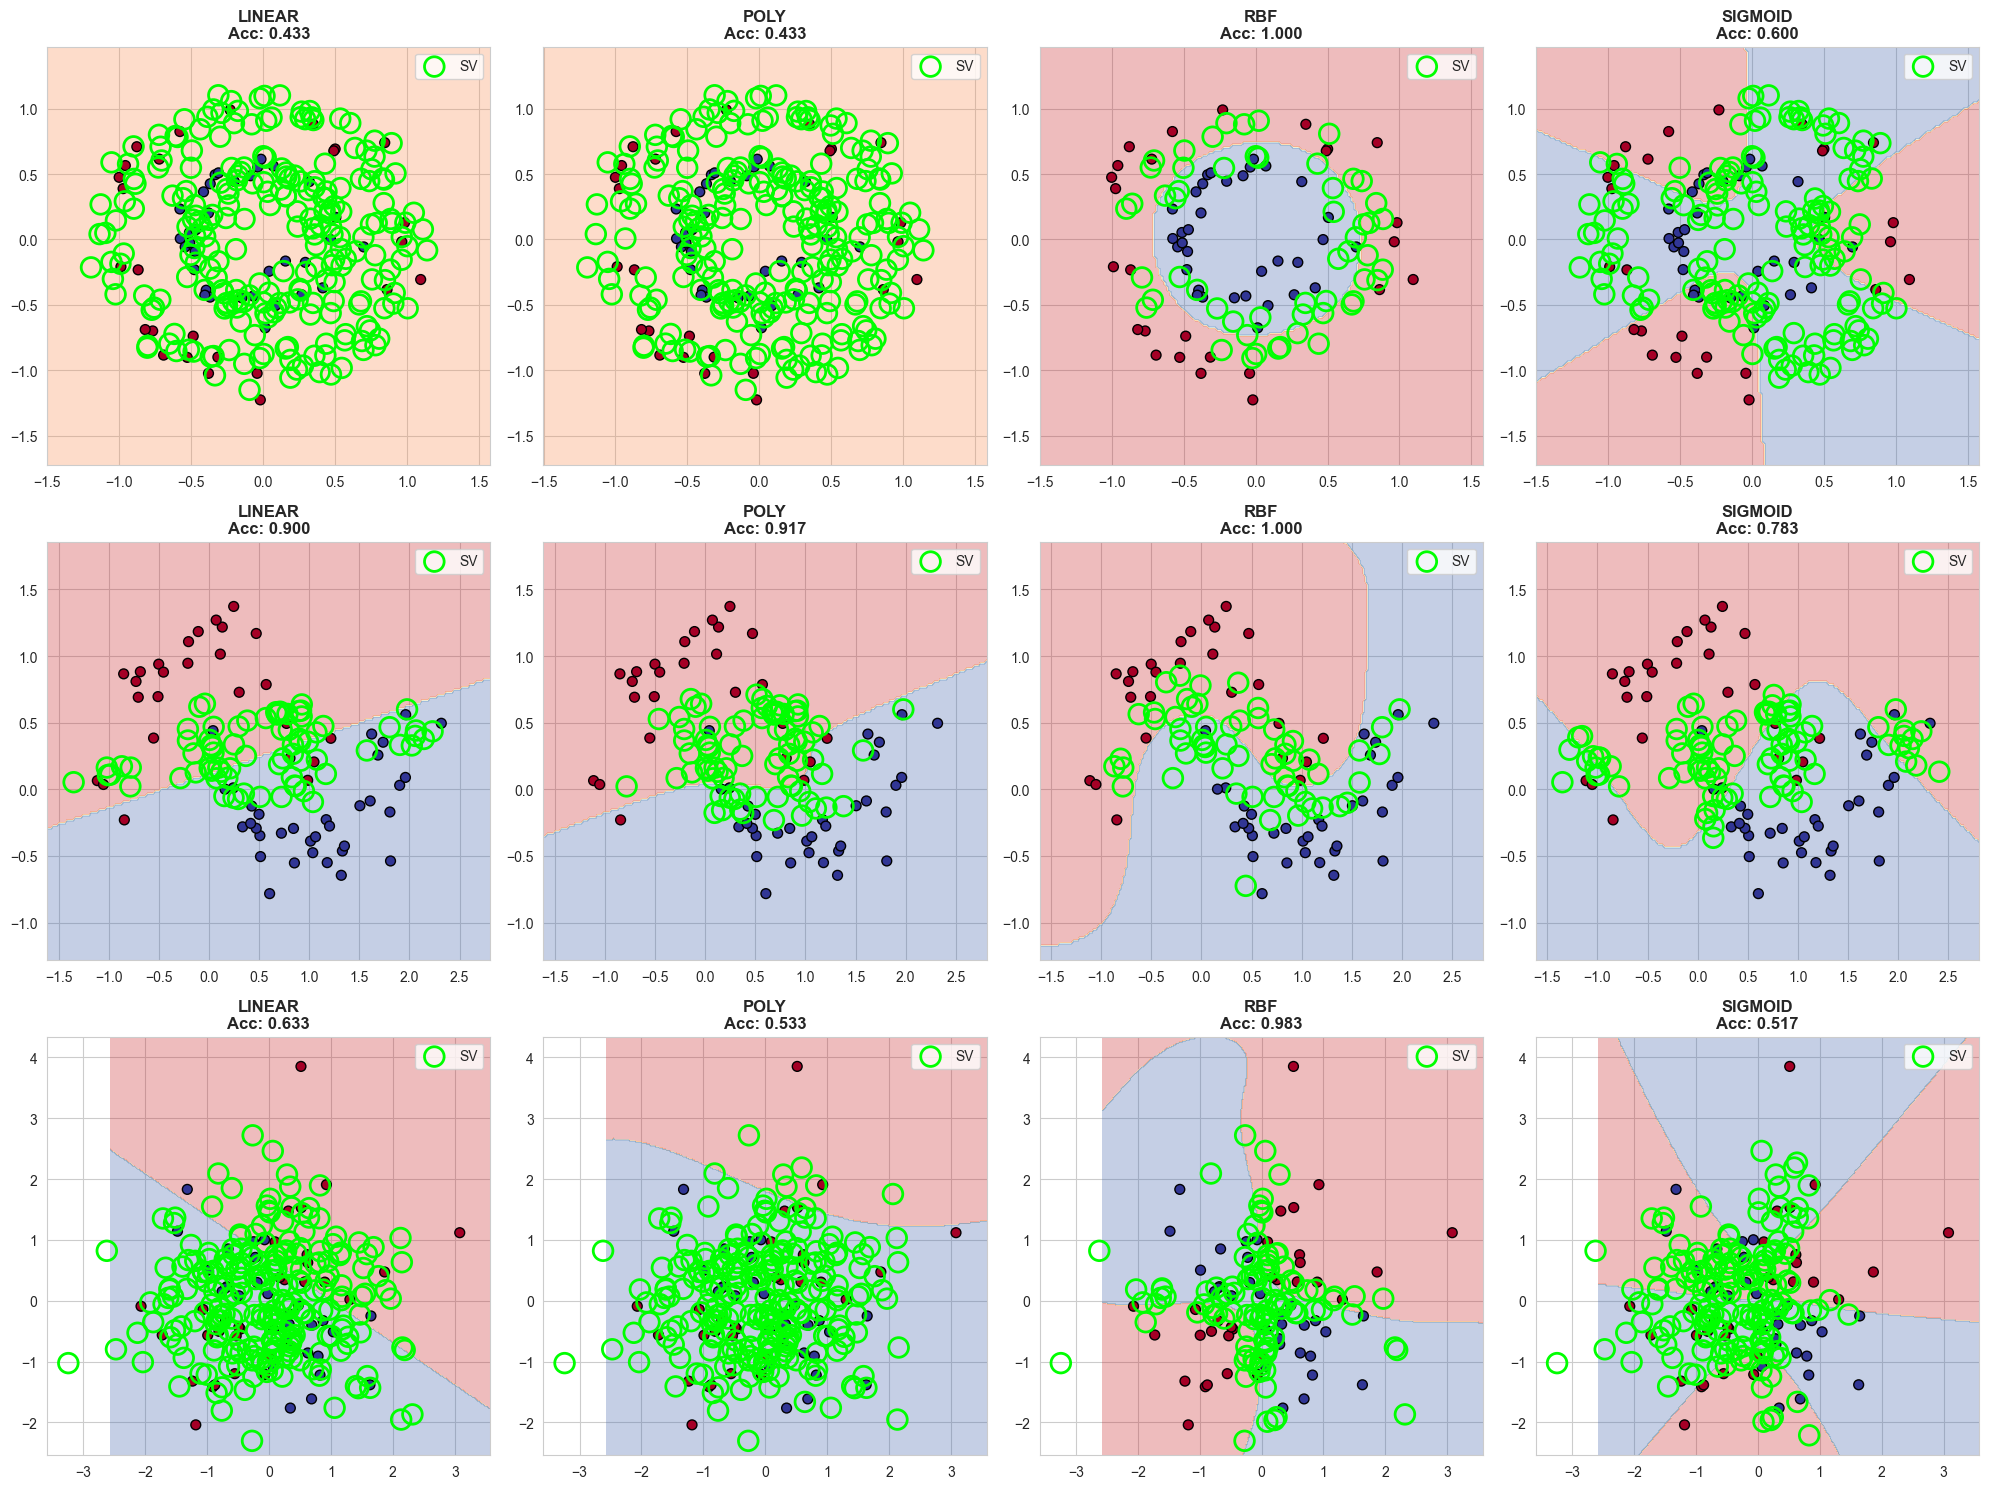


Dataset  Kernel  Accuracy  SV
Circles  LINEAR  0.433333 234
Circles    POLY  0.433333 236
Circles     RBF  1.000000  55
Circles SIGMOID  0.600000 152
  Moons  LINEAR  0.900000  74
  Moons    POLY  0.916667  78
  Moons     RBF  1.000000  60
  Moons SIGMOID  0.783333  88
    XOR  LINEAR  0.633333 230
    XOR    POLY  0.533333 232
    XOR     RBF  0.983333 104
    XOR SIGMOID  0.516667 161


In [30]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results_kernel = []

fig, axes = plt.subplots(3, 4, figsize=(20, 15))

for row, (name, X, y) in enumerate(datasets):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f"\nDataset: {name}")
    
    for col, kernel in enumerate(kernels):
        if kernel == 'poly':
            svm = SVC(kernel=kernel, degree=3, gamma='scale', random_state=42)
        else:
            svm = SVC(kernel=kernel, gamma='scale', random_state=42)
        
        svm.fit(X_train_scaled, y_train)
        y_pred = svm.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        
        results_kernel.append({
            'Dataset': name,
            'Kernel': kernel.upper(),
            'Accuracy': acc,
            'SV': len(svm.support_vectors_)
        })
        
        ax = axes[row, col]
        plot_svm_boundary(svm, X_test, y_test, scaler, 
                         f'{kernel.upper()}\nAcc: {acc:.3f}', ax=ax)
        
        print(f"  {kernel.upper()}: {acc:.4f}")

plt.tight_layout()
plt.show()

df_kernel = pd.DataFrame(results_kernel)
print("\n" + "="*80)
print(df_kernel.to_string(index=False))
print("="*80)

## 3.4. Analisis Best Kernel per Dataset

In [31]:
for dataset_name in ['Circles', 'Moons', 'XOR']:
    subset = df_kernel[df_kernel['Dataset'] == dataset_name]
    best = subset.loc[subset['Accuracy'].idxmax()]
    
    print(f"\n{dataset_name}:")
    print(subset.to_string(index=False))
    print(f"\n→ BEST: {best['Kernel']} ({best['Accuracy']:.4f})")


Circles:
Dataset  Kernel  Accuracy  SV
Circles  LINEAR  0.433333 234
Circles    POLY  0.433333 236
Circles     RBF  1.000000  55
Circles SIGMOID  0.600000 152

→ BEST: RBF (1.0000)

Moons:
Dataset  Kernel  Accuracy  SV
  Moons  LINEAR  0.900000  74
  Moons    POLY  0.916667  78
  Moons     RBF  1.000000  60
  Moons SIGMOID  0.783333  88

→ BEST: RBF (1.0000)

XOR:
Dataset  Kernel  Accuracy  SV
    XOR  LINEAR  0.633333 230
    XOR    POLY  0.533333 232
    XOR     RBF  0.983333 104
    XOR SIGMOID  0.516667 161

→ BEST: RBF (0.9833)


## 3.5. Kesimpulan Karakteristik Kernel

---

# TUGAS 4: Grid Search Optimization (20 poin)

## 4.1. Baseline Model

In [32]:
X, y = cancer.data, cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline
svm_baseline = SVC(random_state=42)
svm_baseline.fit(X_train_scaled, y_train)
baseline_acc = accuracy_score(y_test, svm_baseline.predict(X_test_scaled))

print(f"Baseline Accuracy: {baseline_acc:.4f}")

Baseline Accuracy: 0.9825


## 4.2. Grid Search

In [33]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

print("Running Grid Search...")
grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("\nBEST PARAMETERS:")
print(grid_search.best_params_)
print(f"\nBest CV Score: {grid_search.best_score_:.4f}")

Running Grid Search...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

BEST PARAMETERS:
{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}

Best CV Score: 0.9802


## 4.3. Evaluate Optimized Model

In [34]:
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test_scaled)
optimized_acc = accuracy_score(y_test, y_pred)

print(f"Optimized Accuracy: {optimized_acc:.4f}")
print(f"Improvement: {optimized_acc - baseline_acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

Optimized Accuracy: 0.9825
Improvement: 0.0000

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 4.4. Confusion Matrix Comparison

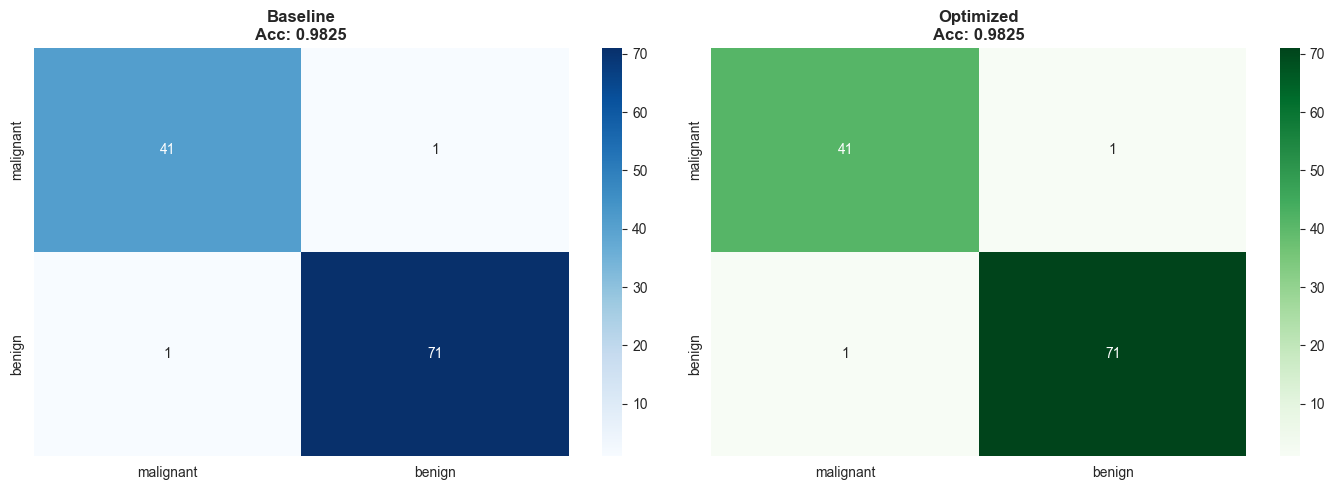

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Baseline
cm_base = confusion_matrix(y_test, svm_baseline.predict(X_test_scaled))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
axes[0].set_title(f'Baseline\nAcc: {baseline_acc:.4f}', fontweight='bold')

# Optimized
cm_opt = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
axes[1].set_title(f'Optimized\nAcc: {optimized_acc:.4f}', fontweight='bold')

plt.tight_layout()
plt.show()

## 4.5. Grid Search Results Visualization

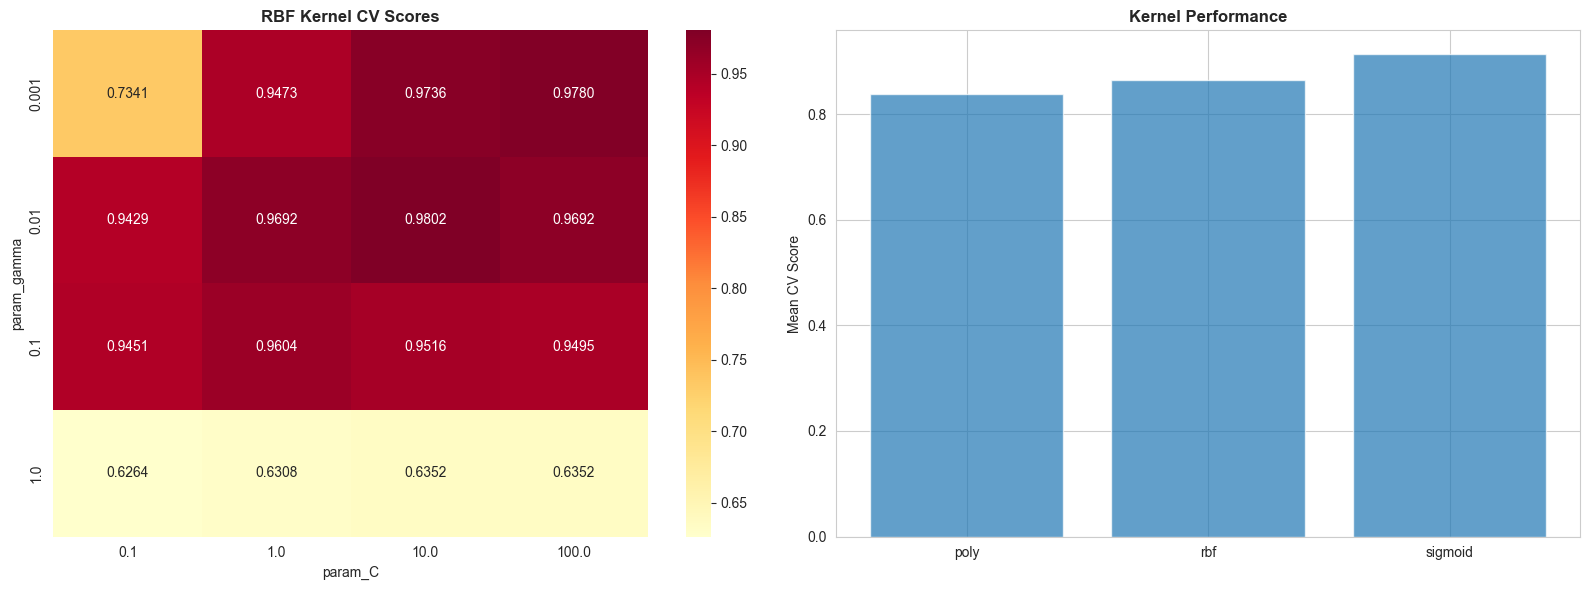

In [36]:
cv_results = pd.DataFrame(grid_search.cv_results_)
rbf_results = cv_results[cv_results['param_kernel'] == 'rbf']

if len(rbf_results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Heatmap
    pivot = rbf_results.pivot_table(
        values='mean_test_score',
        index='param_gamma',
        columns='param_C'
    )
    
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[0])
    axes[0].set_title('RBF Kernel CV Scores', fontweight='bold')
    
    # Bar chart
    kernel_perf = cv_results.groupby('param_kernel')['mean_test_score'].mean()
    axes[1].bar(kernel_perf.index, kernel_perf.values, alpha=0.7)
    axes[1].set_title('Kernel Performance', fontweight='bold')
    axes[1].set_ylabel('Mean CV Score')
    
    plt.tight_layout()
    plt.show()

## 4.6. Interpretasi

**[ISI ANALISIS ANDA DI SINI]**

- Apakah Grid Search membantu?
- Parameter apa yang paling berpengaruh?
- Kesimpulan untuk production?

---

# KESIMPULAN UMUM

**[ISI KESIMPULAN ANDA DI SINI]**

1. Kernel terbaik: ...
2. Parameter optimal: ...
3. Lessons learned: ...
4. Rekomendasi: ...